In [60]:
import glob
import pickle
import lzma

# Find all record files
record_files = sorted(glob.glob("../optimal_runs_DONOTDELETE/run_17_harder.npz"))

if not record_files:
    print("No record files found in current directory!")
    print("Looking in parent directory...")
    record_files = sorted(glob.glob("../record_*.npz"))

if not record_files:
    print("ERROR: No record_*.npz files found!")
    exit(1)

print(f"Found {len(record_files)} record files:")
for f in record_files:
    print(f"  - {f}")

# Quick check of first file
print(f"\n=== Checking first file: {record_files[0]} ===")

with lzma.open(record_files[0], "rb") as file:
    data = pickle.load(file)

    print(f"Number of snapshots: {len(data)}")
    print(f"Type of snapshot: {type(data[0])}")

    # Check first snapshot
    snapshot = data[0]
    print(f"\nFirst snapshot attributes:")
    print(f"  - Controls: {snapshot.current_controls}")
    print(f"  - Car position: {snapshot.car_position}")
    print(f"  - Car speed: {snapshot.car_speed}")
    print(f"  - Car angle: {snapshot.car_angle}")
    print(f"  - Raycast distances: {len(snapshot.raycast_distances)} values")
    print(f"  - Image: {snapshot.image.shape if snapshot.image is not None else 'None (not recorded)'}")

    # Count images
    with_images = sum(1 for s in data if s.image is not None)
    without_images = sum(1 for s in data if s.image is None)

    print(f"\n=== Image Recording Status ===")
    print(f"Snapshots WITH images: {with_images} ({with_images/len(data)*100:.1f}%)")
    print(f"Snapshots WITHOUT images: {without_images} ({without_images/len(data)*100:.1f}%)")

    if with_images > 0:
        print("\n✓ Images ARE being recorded!")
        for i, s in enumerate(data):
            if s.image is not None:
                print(f"  First image found at snapshot #{i}")
                print(f"  Image shape: {s.image.shape}")
                print(f"  Image dtype: {s.image.dtype}")
                break
    else:
        print("\n✗ NO images recorded in this file!")
        print("  Remember to check the 'Save Images' checkbox when recording.")

Found 1 record files:
  - ../optimal_runs_DONOTDELETE/run_17_harder.npz

=== Checking first file: ../optimal_runs_DONOTDELETE/run_17_harder.npz ===


AttributeError: Can't get attribute 'ControlSnapshot' on <module '__main__'>

In [51]:
# Find frames without images
frames_without_images = []

for i, snapshot in enumerate(data):
    if snapshot.image is None:
        frames_without_images.append(i)

print("\n=== Frames Missing Images ===")
print(f"Total frames without images: {len(frames_without_images)}")

if frames_without_images:
    print(f"Frame numbers: {frames_without_images}")

    # Show details about each missing frame
    for frame_num in frames_without_images:
        s = data[frame_num]
        print(f"\nFrame {frame_num}:")
        print(f"  Controls: {s.current_controls}")
        print(f"  Position: {s.car_position}")
        print(f"  Speed: {s.car_speed}")
        print(f"  Angle: {s.car_angle}")
else:
    print("All frames have images!")



=== Frames Missing Images ===
Total frames without images: 0
All frames have images!


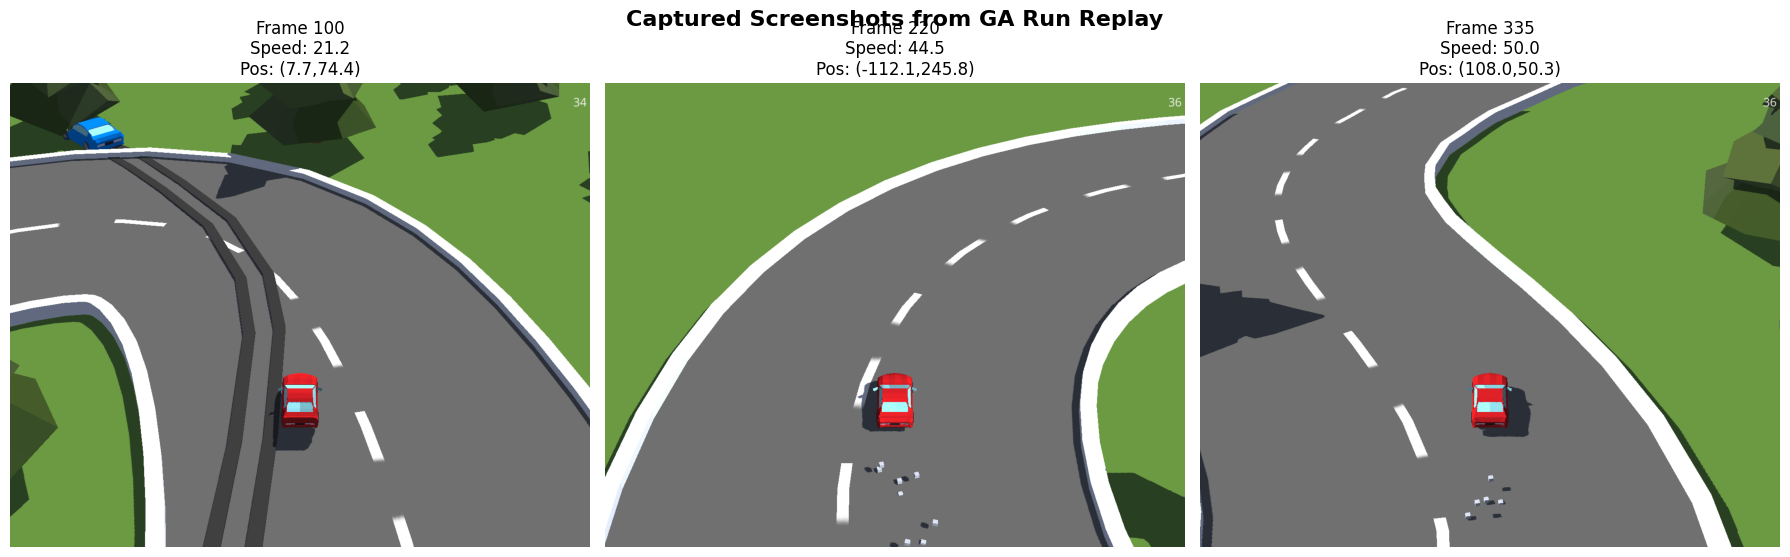


=== Frame Details ===

Frame 100:
  Controls: F=False B=True L=True R=False
  Position: (7.71, 1.00, 74.38)
  Speed: 21.25 units/s
  Angle: 94.7°
  Min raycast distance: 8.07 units

Frame 220:
  Controls: F=True B=False L=False R=True
  Position: (-112.12, 1.00, 245.79)
  Speed: 44.50 units/s
  Angle: -4.3°
  Min raycast distance: 10.43 units

Frame 335:
  Controls: F=True B=False L=True R=False
  Position: (108.05, 1.00, 50.25)
  Speed: 50.00 units/s
  Angle: 220.0°
  Min raycast distance: 7.87 units


In [58]:
import matplotlib.pyplot as plt

# Display images from frames 100, 200, 300
frames_to_show = [100, 220, 335]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Captured Screenshots from GA Run Replay', fontsize=16, fontweight='bold')

for idx, frame_num in enumerate(frames_to_show):
  snapshot = data[frame_num]

  if snapshot.image is not None:
      axes[idx].imshow(snapshot.image)
      axes[idx].set_title(f'Frame {frame_num}\n'
                         f'Speed: {snapshot.car_speed:.1f}\n'
                         f'Pos: ({snapshot.car_position[0]:.1f},{snapshot.car_position[2]:.1f})',
                         fontsize=12)
      axes[idx].axis('off')
  else:
      axes[idx].text(0.5, 0.5, 'No Image',
                    ha='center', va='center', fontsize=14)
      axes[idx].set_title(f'Frame {frame_num}\n(No screenshot)', fontsize=12)
      axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Print additional info
print("\n=== Frame Details ===")
for frame_num in frames_to_show:
  s = data[frame_num]
  print(f"\nFrame {frame_num}:")
  print(f"  Controls: F={s.current_controls[0]} B={s.current_controls[1]} L={s.current_controls[2]} R={s.current_controls[3]}")
  print(f"  Position: ({s.car_position[0]:.2f}, {s.car_position[1]:.2f}, {s.car_position[2]:.2f})")
  print(f"  Speed: {s.car_speed:.2f} units/s")
  print(f"  Angle: {s.car_angle:.1f}°")
  print(f"  Min raycast distance: {min(s.raycast_distances):.2f} units")

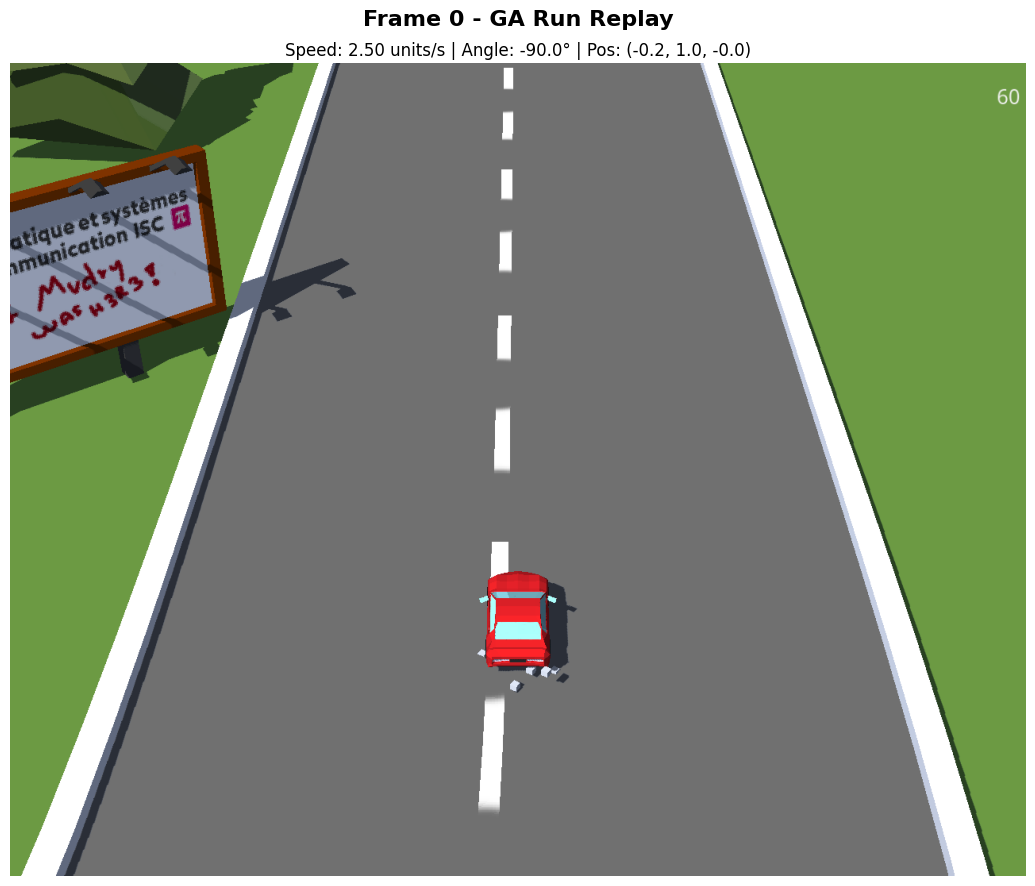


FRAME 0 DETAILS

Controls:
  Forward:  True
  Backward: False
  Left:     False
  Right:    False

Car State:
  Position: (-0.250, 1.000, -0.000)
  Speed: 2.500 units/s
  Angle: -90.00°
  Rotation Speed: 0.000

Proximity Sensors (15 rays):
  Min distance: 11.84 units
  Max distance: 100.00 units
  Average distance: 27.02 units
  Values: [12.0, 12.3, 13.3, 15.3, 19.1, 27.5, 53.5, 100.0, 53.5, 27.4, 19.1, 15.2, 13.2, 12.2, 11.8]

Image:
  Shape: (1024, 1280, 3)
  Size: 3840.0 KB
  Dtype: uint8



In [44]:
# === PARAMETER: Set which frame to display ===
FRAME = 0

# Display single frame
snapshot = data[FRAME]

fig, ax = plt.subplots(1, 1, figsize=(12, 9))
fig.suptitle(f'Frame {FRAME} - GA Run Replay', fontsize=16, fontweight='bold')

if snapshot.image is not None:
    ax.imshow(snapshot.image)
    ax.set_title(
        f'Speed: {snapshot.car_speed:.2f} units/s | '
        f'Angle: {snapshot.car_angle:.1f}° | '
        f'Pos: ({snapshot.car_position[0]:.1f}, '
        f'{snapshot.car_position[1]:.1f}, '
        f'{snapshot.car_position[2]:.1f})',
        fontsize=12
    )
    ax.axis('off')
else:
    ax.text(
        0.5, 0.5, 'No Image Available',
        ha='center', va='center', fontsize=16
    )
    ax.set_title(f'Frame {FRAME} (No screenshot)', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Detailed frame info
print(f"\n{'='*60}")
print(f"FRAME {FRAME} DETAILS")
print(f"{'='*60}")

print("\nControls:")
print(f"  Forward:  {bool(snapshot.current_controls[0])}")
print(f"  Backward: {bool(snapshot.current_controls[1])}")
print(f"  Left:     {bool(snapshot.current_controls[2])}")
print(f"  Right:    {bool(snapshot.current_controls[3])}")

print("\nCar State:")
print(f"  Position: ({snapshot.car_position[0]:.3f}, "
      f"{snapshot.car_position[1]:.3f}, "
      f"{snapshot.car_position[2]:.3f})")
print(f"  Speed: {snapshot.car_speed:.3f} units/s")
print(f"  Angle: {snapshot.car_angle:.2f}°")
print(f"  Rotation Speed: {snapshot.rotation_speed:.3f}")

print(f"\nProximity Sensors ({len(snapshot.raycast_distances)} rays):")
print(f"  Min distance: {min(snapshot.raycast_distances):.2f} units")
print(f"  Max distance: {max(snapshot.raycast_distances):.2f} units")
print(f"  Average distance: "
      f"{sum(snapshot.raycast_distances)/len(snapshot.raycast_distances):.2f} units")

raycast_str = ", ".join([f"{d:.1f}" for d in snapshot.raycast_distances])
print(f"  Values: [{raycast_str}]")

print("\nImage:")
if snapshot.image is not None:
    print(f"  Shape: {snapshot.image.shape}")
    print(f"  Size: {snapshot.image.nbytes / 1024:.1f} KB")
    print(f"  Dtype: {snapshot.image.dtype}")
else:
    print("  None (not captured)")

print(f"\n{'='*60}")
